# numpy + scipy — Equity curve analytics & drawdown attribution

## Project goal

Compute equity curves and drawdowns for each crypto asset, characterise the return distribution (moments + normality test), and bootstrap a 95% CI on annualised Sharpe per asset. Produce one summary table comparing all four assets on (Sharpe, CI, max drawdown, drawdown duration, kurtosis).


## Why this exercises the cheatsheet

Equity-curve and drawdown analysis is *fundamentally* numpy work — cumulative products, running maxima, vectorised broadcasting. scipy.stats covers the distributional characterisation (skew/kurtosis/Jarque-Bera). Forces you to stay vectorised; any `for` loop here is a code smell.


## Sub-task 1: Build equity curves from log returns

Load the parquet, compute hourly log returns per symbol, then build a per-symbol equity curve assuming start-equity = 1.0. The equity at time t is `exp(cumsum(log_returns up to t))`. Plot all four curves on one chart for sanity (you can use matplotlib for this step).

**Patterns this forces:**

- `np.log(close).diff()` (or pandas equivalent — wrap in `np.asarray` for the math steps)
- `np.cumsum` to get cumulative log returns
- `np.exp` to convert to equity multiplier
- broadcasting across the (n_steps, n_symbols) array


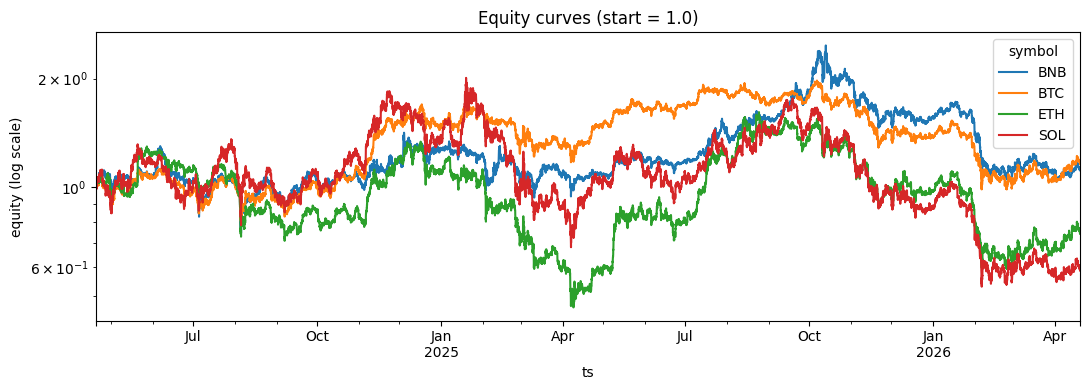

In [1]:
# Your answer here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet('./../../data/crypto_hourly.parquet').sort_values(['symbol', 'ts'])

# log returns per symbol
df['logret'] = (
    df
    .groupby('symbol')['close']
    .transform(lambda c: np.log(c).diff())
)

logret = df.pivot(index='ts', columns='symbol', values='logret').fillna(0)
equity = np.exp(np.cumsum(logret))

equity.plot(figsize=(11,4), logy=True, title='Equity curves (start = 1.0)')
plt.ylabel('equity (log scale)')
plt.tight_layout()
plt.show()

## Sub-task 2: Drawdowns via running max

For each asset, compute the drawdown series: `(equity - running_max) / running_max`. Use `np.maximum.accumulate(equity)` (vectorised). Report max drawdown per asset and the timestamp at which it occurred.

**Patterns this forces:**

- `np.maximum.accumulate` (NOT a `for` loop)
- `np.argmin` to locate the worst drawdown
- broadcasting `(equity - running_max) / running_max`


In [2]:
# Your answer here

running_max = np.maximum.accumulate(equity)

drawdowns = (equity - running_max) / running_max

max_dd = -drawdowns.min()
dd_at = drawdowns.idxmin()

print(pd.DataFrame({'max_dd': max_dd.round(4), 'date': dd_at}))

        max_dd                      date
symbol                                  
BNB     0.5812 2026-04-02 13:00:00+00:00
BTC     0.5008 2026-02-24 13:00:00+00:00
ETH     0.6528 2025-04-09 03:00:00+00:00
SOL     0.7362 2026-02-06 00:00:00+00:00


## Sub-task 3: Drawdown duration

For each asset, find the longest 'underwater' stretch: the run of consecutive bars where drawdown < 0. Report the start, end, and duration in hours. Hint: a boolean mask + `np.diff` on the run-length encoded transitions.

**Patterns this forces:**

- boolean mask + `np.diff` for run-length encoding
- `np.where` to find transition indices
- vectorised search across the array


In [3]:
# Your answer here

underwater = (drawdowns < 0).astype(int).values # (T, n_assets), 0/1

rows = []
for i, s in enumerate(drawdowns.columns):
    # pad both ends with 0 so runs starting at index 0 or ending at T-1 are captured.
    padded = np.concatenate([[0], underwater[:, i], [0]])
    padded_diff = np.diff(padded)
    starts = np.where(padded_diff == 1)[0] # indices where underwater starts
    ends = np.where(padded_diff == -1)[0] # indices of first dry bar after underwater ends
    
    durations = ends - starts # number of bars underwater
    
    i_longest = durations.argmax() # position of the longest run inside starts/ends
    start_ts = equity.index[starts[i_longest]] # start timestamp in original dataframe
    end_ts = equity.index[ends[i_longest] - 1] # end timestamp in original dataframe
    
    duration_hours = durations[i_longest] # duration in number of bars
    duration_days = duration_hours // 24

    rows.append([s, start_ts, end_ts, duration_hours, duration_days])


pd.DataFrame(rows, columns=['symbol', 'start', 'end', 'duration_hrs', 'duration_days'])

# Observations:
# - SOL is is underwater for the longest out of all symbols, ~11k hrs or 455 days, ~63% of the 17.5k hours
# - Shortest underwater is BTC @ 4.6k hrs or 195 days, ~26%
# - This give a good idea of the market sentiment at the moment - bearish since all symbols have been underwater for over half a year
# - BNB is the only symbol where it's longest duration underwater is not the most recent period

,symbol,start,end,duration_hrs,duration_days
0,BNB,2024-12-04 11:00:00+00:00,2025-07-22 22:00:00+00:00,5532,230
1,BTC,2025-10-06 19:00:00+00:00,2026-04-19 22:00:00+00:00,4684,195
2,ETH,2025-08-24 19:00:00+00:00,2026-04-19 22:00:00+00:00,5716,238
3,SOL,2025-01-19 12:00:00+00:00,2026-04-19 22:00:00+00:00,10931,455


## Sub-task 4: Distributional moments

For each asset's hourly log returns, compute skew, excess kurtosis (Fisher), and the Jarque-Bera test for normality. Produce a small DataFrame with columns `(asset, skew, excess_kurt, jb_stat, jb_pvalue, is_normal_at_5pct)`.

**Patterns this forces:**

- `scipy.stats.skew`, `scipy.stats.kurtosis(fisher=True)`
- `scipy.stats.jarque_bera`
- vectorised iteration over assets (dict comprehension or apply across columns)


In [24]:
# Your answer here

from scipy import stats

skew = stats.skew(logret, axis=0)
kurt = stats.kurtosis(logret, axis=0)
jb_stats, jb_pvalue = stats.jarque_bera(logret.values, axis=0)

rows = {
    'assets': logret.columns.tolist(),
    'skew': skew,
    'excess_kurt': kurt,
    'jb_stat': jb_stats,
    'jb_pvalue': jb_pvalue,
    'is_normal_at_5pct': jb_pvalue > 0.05
}

pd.DataFrame(rows)

# Observations
# - All four assets reject normality at any α (JB p ≈ 0).
# - Excess kurtosis is uniformly high (BTC 9, ETH 17): a 4σ move is
#   ~200-250× more likely than Gaussian. Parametric VaR/CIs on these
#   series will be biased.
# - BTC, ETH, BNB show strong negative skew (-0.4 to -0.6): big losses
#   exceed big gains. Consistent with crypto crash dynamics.
# - SOL's small positive skew (+0.1) is likely sample noise on heavy
#   tails; would need a bootstrap CI to confirm.
# - ETH's combination of heaviest tails + negative skew makes its worst
#   losses the most extreme of the four.
# - Implication: Sharpe is misleading here (assumes Gaussian).

,assets,skew,excess_kurt,jb_stat,jb_pvalue,is_normal_at_5pct
0,BNB,-0.642353,14.088615,146101.857331,0.0,False
1,BTC,-0.170411,9.419183,64851.137391,0.0,False
2,ETH,-0.380002,16.798916,206430.269793,0.0,False
3,SOL,0.110191,9.866797,71103.643763,0.0,False


## Sub-task 5: Bootstrap annualised Sharpe with 95% CI

For each asset, bootstrap the annualised Sharpe ratio: resample hourly returns with replacement, compute Sharpe = `mean / std * sqrt(24*365)`, repeat 1000×, return [2.5%, 97.5%] percentiles. Use `np.random.default_rng` and integer indices, NOT a pandas-row resample.

**Patterns this forces:**

- `rng.integers(0, n, n)` for index resampling
- vectorised mean / std on each resample
- `np.quantile(boot_samples, [0.025, 0.975])`


In [82]:
# Your answer here

SEED = 42
rng = np.random.default_rng(SEED)
n_boot = 1000
ann = np.sqrt(24 * 365)

clean = logret.dropna()
arr = clean.values
n = arr.shape[0]

# sample returns for each asset and compute sharpe 1000 times
idx = rng.integers(0, n, size=(n_boot, n)) # sample returns indices
boot = arr[idx] # fancy return indexing
boot_sharpe = boot.mean(axis=1) / boot.std(axis=1) * ann

ci = np.quantile(boot_sharpe, [0.025, 0.975], axis=0)

pd.DataFrame(ci.T, index=clean.columns, columns=['sharpe_lo', 'sharpe_hi'])



,sharpe_lo,sharpe_hi
symbol,,
BNB,-1.311607,1.426755
BTC,-1.250810,1.497290
ETH,-1.609715,1.110558
SOL,-1.833522,1.110667


## Sub-task 6: Two-sample distribution test (KS + Welch)

Test whether BTC and ETH hourly returns come from the same distribution (KS test) AND have the same mean (Welch's t-test). Report p-values and interpret in plain English: do they look statistically different on either dimension?

**Patterns this forces:**

- `scipy.stats.ks_2samp`
- `scipy.stats.ttest_ind(equal_var=False)`
- interpretation in plain English in a comment


In [105]:
# Your answer here

btc = logret['BTC'].dropna().values
eth = logret['ETH'].dropna().values

ks = stats.ks_2samp(btc, eth)
welch = stats.ttest_ind(btc, eth, equal_var=False)

pd.DataFrame({
    'statistic': [ks.statistic, welch.statistic],
    'pvalue': [ks.pvalue, welch.pvalue],
    'reject_at_5pct': [ks.pvalue < 0.05, welch.pvalue < 0.05]
}, index=['KS (distribution)', 'Welch (mean)']).round(5)

# Observation:
# - ETH and BTC have statistically different returns distribution, pvalue under the KS test is ~0
# - Mean of the returns are highly likely to be the same under the Welch test - pvalue is 0.7 

,statistic,pvalue,reject_at_5pct
KS (distribution),0.07426,0.00000,True
Welch (mean),0.37944,0.70436,False


## Sub-task 7: Final summary table

Combine outputs from sub-tasks 2, 4, 5 into one DataFrame: per asset, (max_drawdown, max_dd_duration_hours, skew, kurtosis, sharpe_lo, sharpe_hi, jb_pvalue). This is the deliverable.

**Patterns this forces:**

- `pd.DataFrame(rows)` from a list of dicts
- consistent column ordering
- rounding for readability via `.round(...)`


In [129]:
arr[None, :]

array([[[ 0.        ,  0.        ,  0.        ,  0.        ],
        [-0.00470419, -0.00586977, -0.00851986, -0.01242778],
        [ 0.00992519,  0.00332792,  0.00679743,  0.00940568],
        ...,
        [-0.00307087, -0.00448504, -0.00831399, -0.00458097],
        [-0.00090215, -0.00274865, -0.00198389, -0.00282952],
        [-0.00547867, -0.00470854, -0.00214193, -0.01151827]]],
      shape=(1, 17520, 4))

In [130]:
# Your answer here

# pd.DataFrame({'max_dd': max_dd.round(4), 'date': dd_at})
rng = np.random.default_rng(42)

n_samples = len(logret)
n_boot = 1000

indx = rng.integers(0, n_samples, size=(n_boot, n_samples))
boot_z = (arr[None, :] - arr[indx].mean(axis=1, keepdims=True)) / arr[indx].std(axis=1, keepdims=True)

np.quantile(boot_z, q=[0.025,0.975], axis=0)
# sharpe_test.shape
# boot_z

array([[[-0.01524395, -0.01599756, -0.01186558, -0.01186675],
        [-0.8299292 , -1.19607929, -1.20530401, -1.4366651 ],
        [ 1.63746093,  0.63608221,  0.90202878,  1.03611582],
        ...,
        [-0.54598924, -0.9166765 , -1.17636728, -0.53383705],
        [-0.17058283, -0.56618504, -0.28713827, -0.33338041],
        [-0.96505429, -0.96173743, -0.3091393 , -1.33211487]],

       [[ 0.01401366,  0.01336409,  0.01719875,  0.01958998],
        [-0.77134979, -1.1315958 , -1.12730654, -1.36260937],
        [ 1.73460856,  0.67779544,  0.9650037 ,  1.09555554],
        ...,
        [-0.50071848, -0.86310689, -1.09987039, -0.49526127],
        [-0.13756488, -0.52606798, -0.25192513, -0.29937462],
        [-0.89979222, -0.90645887, -0.27338756, -1.26225251]]],
      shape=(2, 17520, 4))

## What success looks like

- One summary table with one row per asset, ~7 columns.
- All numeric work is vectorised: zero `for` loops over rows.
- Bootstrap completes in <2 seconds per asset (uses array indexing, not iteration).
- You can answer at a glance: which asset has the best risk-adjusted return, and is the difference statistically significant?
